<a href="https://colab.research.google.com/github/harini020306/AI-ML_HOTEL_BOOKING_CANCELLATION_PREDICTION/blob/main/AIML_CT_PROJECTS2_07_07_26_HARINI_K_ECE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Classification Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Save Model
import pickle

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/content/hotel_booking_cancellation_dataset_1000.csv")
df

,hotel,lead_time,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,previous_cancellations,booking_changes,deposit_type,customer_type,adr,required_car_parking_spaces,total_of_special_requests,is_canceled
0,City Hotel,12,September,2,4,2,0,0,BB,DEU,Groups,Direct,0,4,No Deposit,Transient-Party,155.48,0,0,1
1,Resort Hotel,3,June,1,7,3,1,0,FB,IND,Direct,Corporate,1,2,No Deposit,Transient-Party,75.55,0,3,0
2,City Hotel,282,February,2,10,3,2,0,SC,FRA,Direct,Corporate,0,0,Non Refund,Contract,215.32,0,2,0
3,Resort Hotel,181,November,1,5,1,2,0,FB,IND,Offline TA/TO,TA/TO,1,1,Non Refund,Transient-Party,165.57,0,2,1
4,Resort Hotel,33,September,1,10,3,0,1,FB,CAN,Groups,Direct,3,3,Non Refund,Contract,85.72,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Resort Hotel,112,June,1,9,3,0,0,HB,DEU,Offline TA/TO,Direct,2,3,No Deposit,Transient,293.53,1,1,0
996,City Hotel,39,October,0,6,4,1,0,FB,ESP,Corporate,Direct,2,2,Non Refund,Group,142.45,1,3,0
997,Resort Hotel,102,May,2,4,4,1,1,HB,USA,Offline TA/TO,Direct,2,3,Non Refund,Group,146.66,0,3,0
998,City Hotel,274,June,0,10,3,2,1,SC,CAN,Corporate,Direct,0,2,No Deposit,Transient,96.34,0,3,1


In [32]:
df.columns

Index(['hotel', 'lead_time', 'arrival_date_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'previous_cancellations', 'booking_changes', 'deposit_type',
       'customer_type', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'is_canceled', 'total_guests',
       'total_nights'],
      dtype='object')

In [3]:
df.head()
df.tail()
df.shape
df.info()
df.describe()
df.columns
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   hotel                        1000 non-null   object 
 1   lead_time                    1000 non-null   int64  
 2   arrival_date_month           1000 non-null   object 
 3   stays_in_weekend_nights      1000 non-null   int64  
 4   stays_in_week_nights         1000 non-null   int64  
 5   adults                       1000 non-null   int64  
 6   children                     1000 non-null   int64  
 7   babies                       1000 non-null   int64  
 8   meal                         1000 non-null   object 
 9   country                      1000 non-null   object 
 10  market_segment               1000 non-null   object 
 11  distribution_channel         1000 non-null   object 
 12  previous_cancellations       1000 non-null   int64  
 13  booking_changes    

,0
hotel,object
lead_time,int64
arrival_date_month,object
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64
children,int64
babies,int64
meal,object
country,object


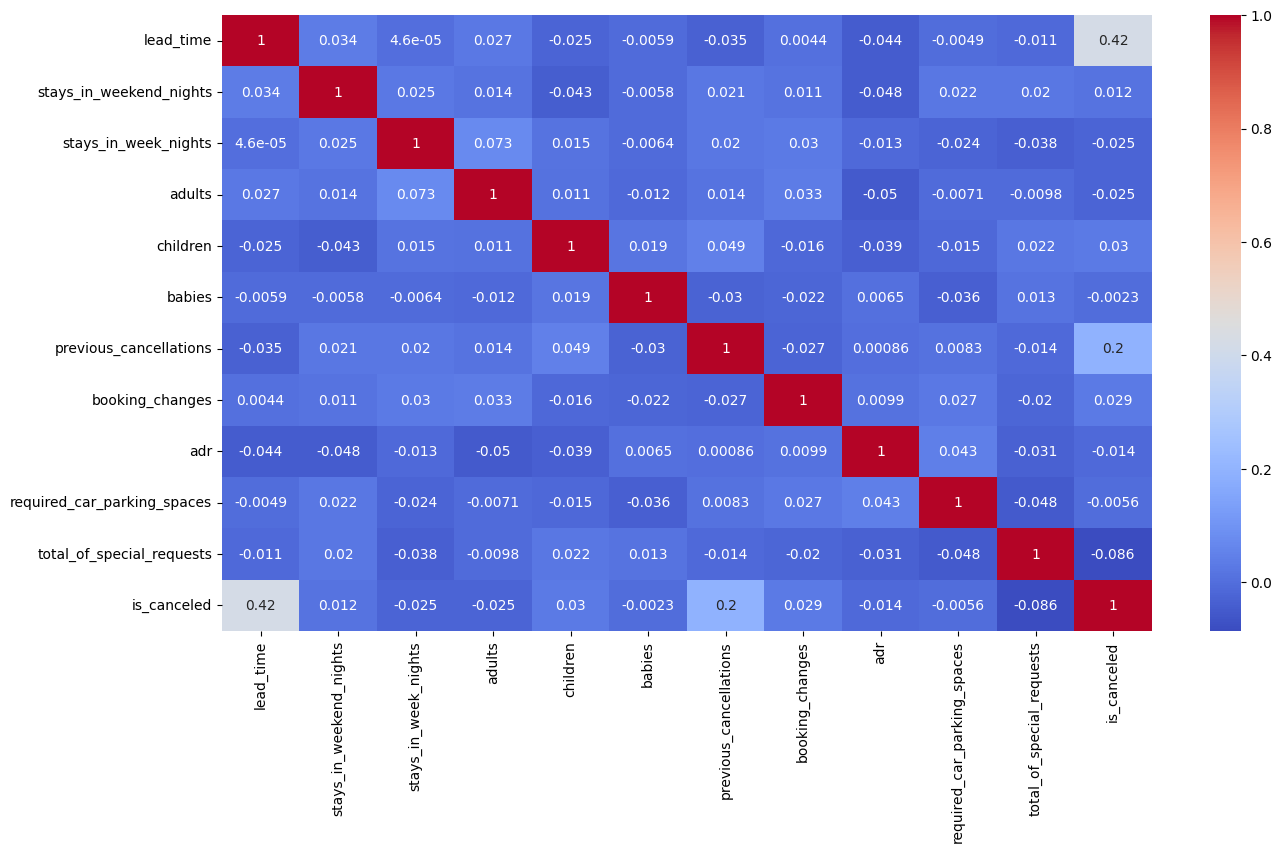

In [4]:
#heat map
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

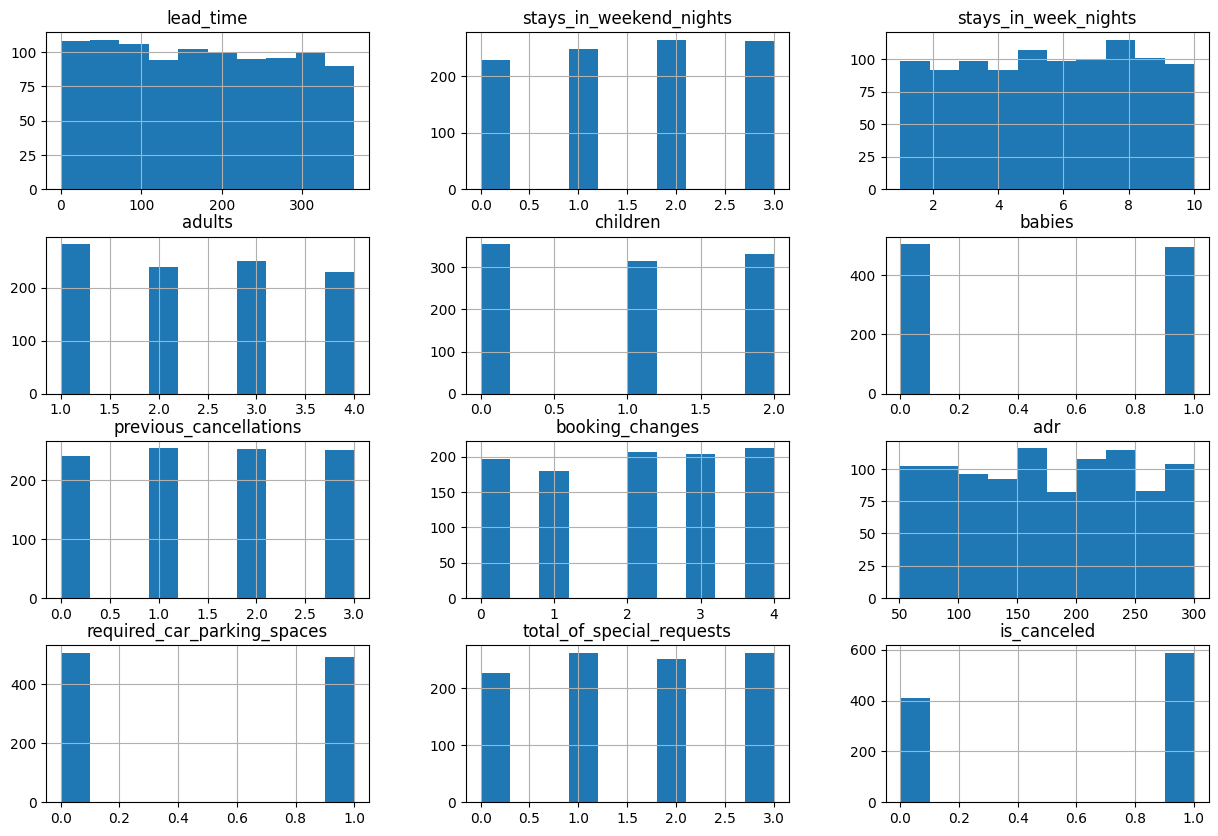

In [5]:
#histogram
df.hist(figsize=(15,10))
plt.show()

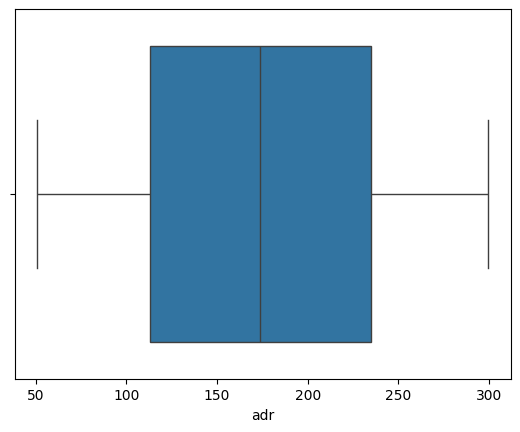

In [6]:
#box plot
sns.boxplot(x=df["adr"])
plt.show()

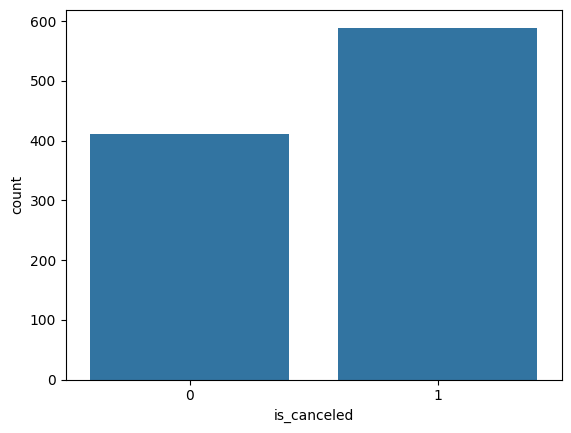

In [7]:
#count plot
sns.countplot(x="is_canceled",data=df)
plt.show()

In [8]:
#data cleaning
# Missing Values
df.isnull().sum()

# Fill Missing Values
df["children"] = df["children"].fillna(0)

# Remove Duplicates
df = df.drop_duplicates()

In [9]:
#feature engineering
df["total_guests"] = df["adults"] + df["children"] + df["babies"]

df["total_nights"] = df["stays_in_week_nights"] + df["stays_in_weekend_nights"]

In [10]:
#feature selection
X = df.drop("is_canceled",axis=1)

y = df["is_canceled"]

In [11]:
#encoding catagorical data
le = LabelEncoder()

for col in X.select_dtypes(include="object"):
    X[col] = le.fit_transform(X[col].astype(str))

In [12]:
#feature scaling
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [13]:
#split the data
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [14]:
#choose ml algorithm
lr = LogisticRegression()

dt = DecisionTreeClassifier()

rf = RandomForestClassifier()

knn = KNeighborsClassifier()

svm = SVC()

In [15]:
#logistic algorithm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.665


In [16]:
#disition tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.685


In [17]:
#random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.765


In [18]:
#knn
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.605


In [19]:
#svm
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.66


In [20]:
accuracy_dict = {
    "Logistic Regression": lr_accuracy,
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy,
    "KNN": knn_accuracy,
    "SVM": svm_accuracy
}

for model, acc in accuracy_dict.items():
    print(f"{model}: {acc:.4f}")

Logistic Regression: 0.6650
Decision Tree: 0.6850
Random Forest: 0.7650
KNN: 0.6050
SVM: 0.6600


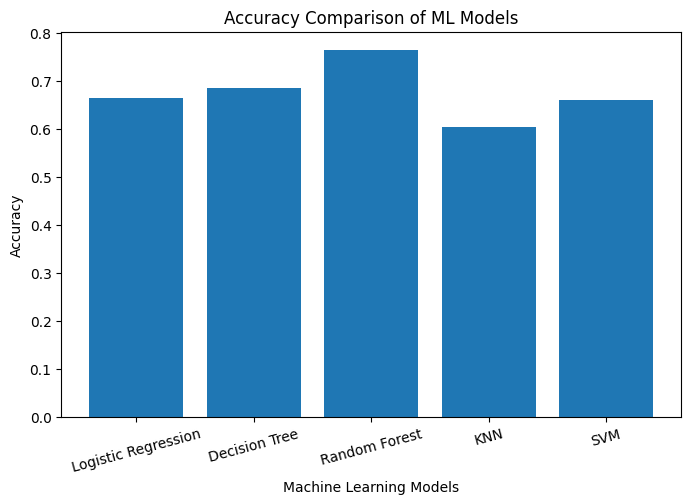

In [21]:
#compare
import matplotlib.pyplot as plt

models = list(accuracy_dict.keys())
accuracies = list(accuracy_dict.values())

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Accuracy Comparison of ML Models")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()

In [22]:
#best_model
best_model = max(accuracy_dict, key=accuracy_dict.get)

print("Best Model:", best_model)
print("Best Accuracy:", accuracy_dict[best_model])

Best Model: Random Forest
Best Accuracy: 0.765


In [23]:
#confusion matrix & classification report
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, rf_pred)
print(cm)

print(classification_report(y_test, rf_pred))

[[72 14]
 [33 81]]
              precision    recall  f1-score   support

           0       0.69      0.84      0.75        86
           1       0.85      0.71      0.78       114

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.76       200
weighted avg       0.78      0.77      0.77       200



In [24]:
#hyper tunning
param_grid = {
    "n_estimators":[50,100,200],
    "max_depth":[5,10,None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5
)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'max_depth': None, 'n_estimators': 50}


In [25]:
#save model
with open("hotel_booking_model.pkl","wb") as file:
    pickle.dump(rf,file)

In [26]:
# Save the scaler
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [27]:
#download the pkl file
from google.colab import files

files.download("hotel_booking_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
from google.colab import files

files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
with open("hotel_booking_model.pkl", "wb") as file:
    pickle.dump(rf, file)

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)